In [63]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import yfinance as yf

root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.simulation import MarketSimulator
from src.metrics import MarketMetrics, plot_susceptibility_curve
from scipy.stats import norm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


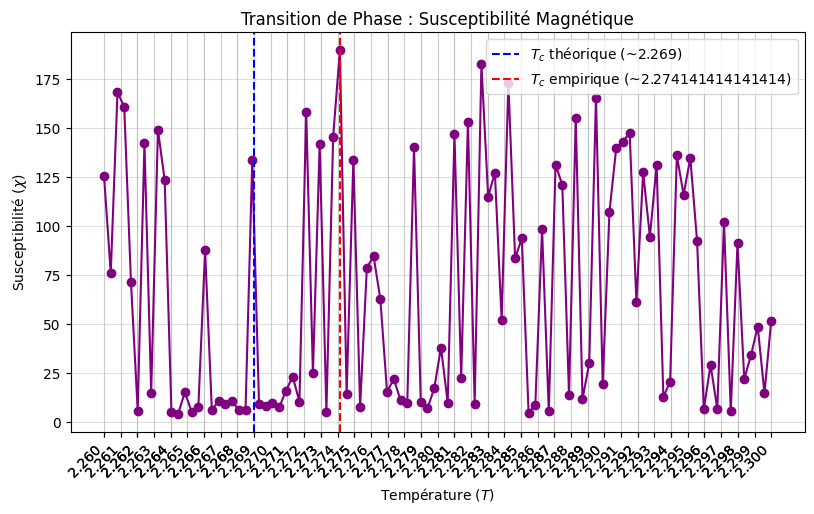

In [64]:
list_T = np.linspace(2.26, 2.3, 100)
dict_results = {}

for T in list_T:
    sim = MarketSimulator(
        N=1000,     
        T=T,        
        J=1.0,       
        h=0.0,      
        Delta_t=8000, 
        P_0=100,  
        lambd_0=100  
    )
    
    filename = sim.run()

    analyzer = MarketMetrics(filename)
    susceptibility = analyzer.calculate_susceptibility(1000, T)
    dict_results[f"{T}"] = susceptibility


T_c = plot_susceptibility_curve(dict_results)

In [65]:
# Initialisation du simulateur
T = T_c 
N = 2000

sim = MarketSimulator(
    N=N,          # Taille du réseau (50x50)
    T=T,        # Température (proche du point critique)
    J=1.0,         # Interaction
    h=0.0,         # Champ externe
    Delta_t=20000,  # Nombre de pas de temps
    P_0=100,       # Prix initial
    lambd_0=100      # Liquidité
)

# Lancement et export automatique en .parquet
filename = sim.run()
df = pd.read_parquet(filename)

<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/0q/z_dwszqd10scbmvs1r972gdh0000gn/T/ipykernel_2926/424077780.py:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax1.set_ylabel('ln Prix ($\ln P_t$)')


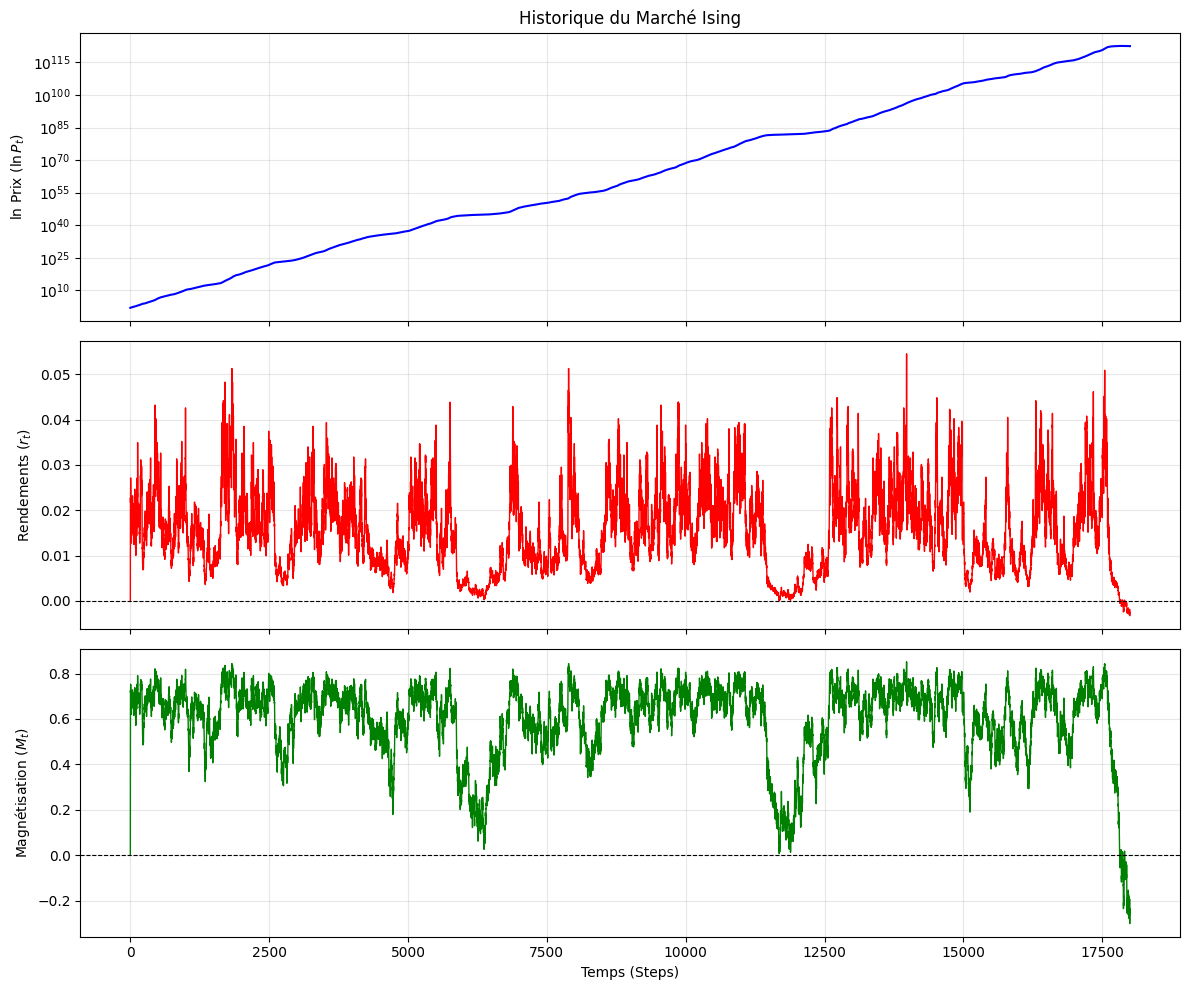

In [66]:
# Création de la figure avec 3 sous-graphiques (subplots)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Graphique du Prix
ax1.semilogy(df['time'], df['P_history'], color='blue', lw=1.5)
ax1.set_ylabel('ln Prix ($\ln P_t$)')
ax1.set_title('Historique du Marché Ising')
ax1.grid(alpha=0.3)

# 2. Graphique des Rendements
ax2.plot(df['time'], df['r_history'], color='red', lw=1)
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_ylabel('Rendements ($r_t$)')
ax2.grid(alpha=0.3)

# 3. Graphique de la Magnétisation
ax3.plot(df['time'], df['m_history'], color='green', lw=1)
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.set_ylabel('Magnétisation ($M_t$)')
ax3.set_xlabel('Temps (Steps)')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

--- Résultats de l'Analyse ---
Volatilité (Ecart-type) : 0.008942700140377737
Asymétrie (Skewness) : 0.5149492721674608
Excès de Kurtosis : -0.1102446821188181
Jarque-Bera p-value : 9.797229870564852e-166
Est une Loi Normale ? : False
Susceptibility : 25.878261999168295


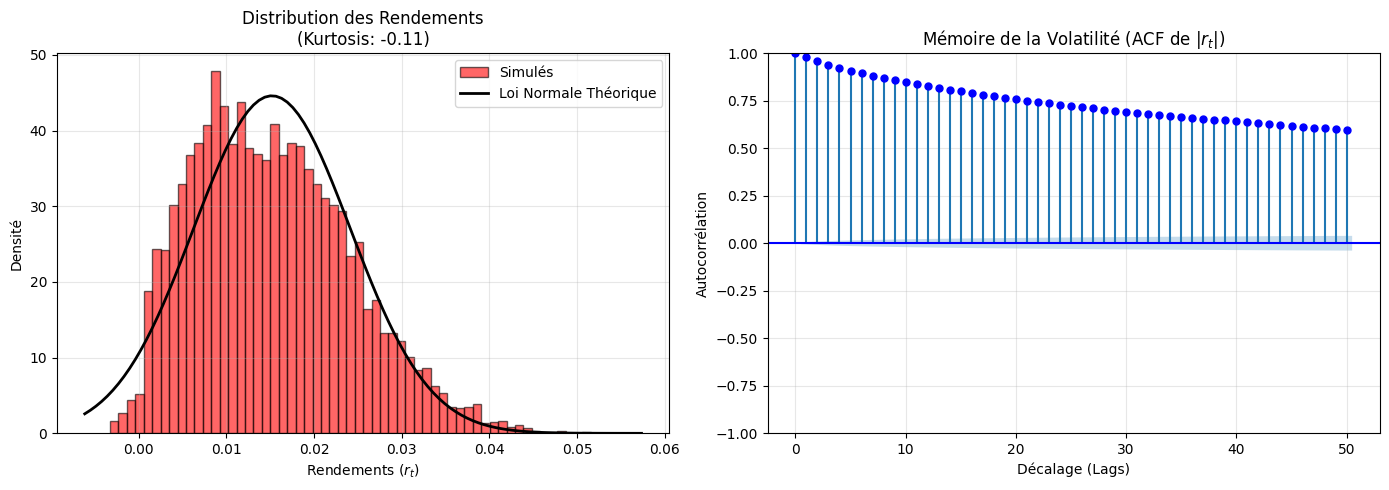

In [67]:
analyzer = MarketMetrics(filename)

financial_stats = analyzer.analyze_returns()

print("--- Résultats de l'Analyse ---")
for metric, valeur in financial_stats.items():
    print(f"{metric} : {valeur}")
    
susceptibility = analyzer.calculate_susceptibility(N, T)
print(f"Susceptibility : {susceptibility}")

# 3. Afficher les graphiques de validation (Histogramme + ACF)
analyzer.plot_stylized_facts(burn_in=1000)

🚀 Lancement du scan de phase (36 simulations)... Cela peut prendre quelques minutes.
✅ Température T=2.10 terminée.
✅ Température T=2.14 terminée.
✅ Température T=2.19 terminée.
✅ Température T=2.23 terminée.
✅ Température T=2.28 terminée.
✅ Température T=2.32 terminée.
✅ Température T=2.37 terminée.
✅ Température T=2.41 terminée.
✅ Température T=2.46 terminée.
✅ Température T=2.50 terminée.


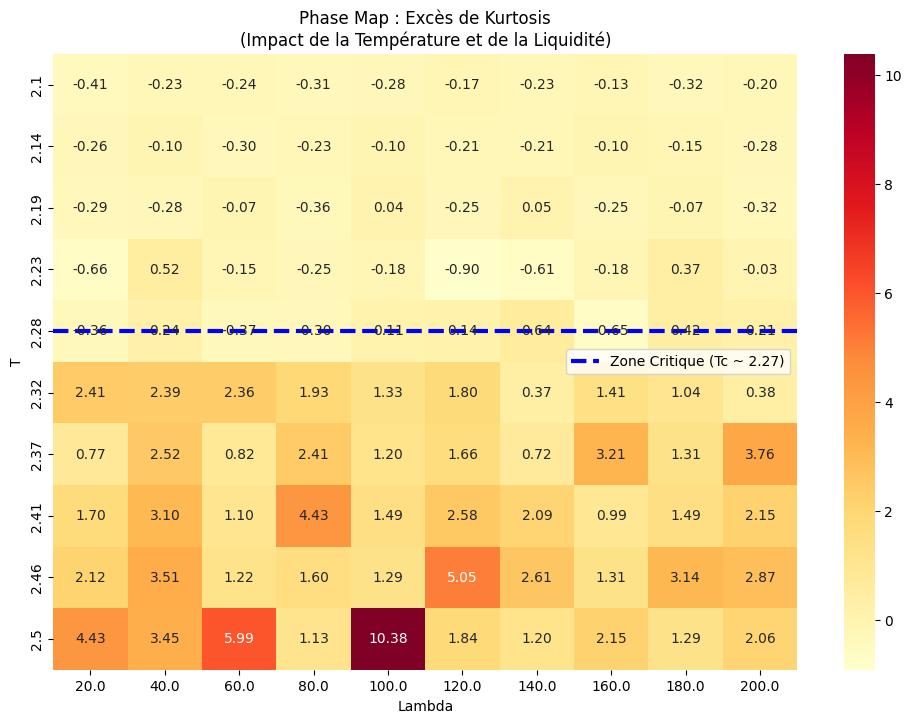

In [68]:
# 1. Paramétrage des plages de test
# On se focalise autour de ton Tc critique pour voir la transition
temp_range = np.linspace(2.1, 2.5, 10)   
# On teste de très liquide (200) à peu liquide (20)
lambda_range = np.linspace(20, 200, 10)  

kurt_max = 0

# Initialisation de la matrice pour stocker le Kurtosis
kurt_matrix = np.zeros((len(temp_range), len(lambda_range)))

print("🚀 Lancement du scan de phase (36 simulations)... Cela peut prendre quelques minutes.")

# 2. Boucle de simulation croisée
for i, T in enumerate(temp_range):
    for j, L in enumerate(lambda_range):
        # On utilise des paramètres un peu plus légers pour que le scan soit rapide
        sim = MarketSimulator(
            N=1000,     
            T=T,        
            J=1.0,       
            h=0.0,      
            Delta_t=8000, 
            P_0=100,  
            lambd_0=L  
        )
        
        # On lance la simulation
        filename = sim.run() 
        
        # On analyse directement le DataFrame en mémoire (plus rapide que lire/écrire des fichiers)
        df = pd.read_parquet(filename)
        analyzer = MarketMetrics(df)
        stats = analyzer.analyze_returns(burn_in=1000)
        
        # On stocke le Kurtosis
        current_kurt = stats["Excès de Kurtosis"]
        kurt_matrix[i, j] = current_kurt
        
        if current_kurt > kurt_max:
            kurt_max = current_kurt
            df_kurt_max = df.copy()
            filename_kurt_max = filename
    
    print(f"✅ Température T={T:.2f} terminée.")

# 3. Création de la Heatmap avec Seaborn
plt.figure(figsize=(12, 8))

# On prépare les données
df_heatmap = pd.DataFrame(
    kurt_matrix, 
    index=np.round(temp_range, 2), 
    columns=np.round(lambda_range, 0)
)

# On trace la heatmap
sns.heatmap(df_heatmap, annot=True, fmt=".2f", cmap="YlOrRd")

# --- CORRECTION DE LA LIGNE BLEUE ---
# On cherche l'indice de la température la plus proche de 2.27
tc_theorique = T_c
# On trouve quelle ligne (0, 1, 2...) correspond au T le plus proche
idx_proche = np.argmin(np.abs(temp_range - tc_theorique))

# On ajoute la ligne (0.5 permet de centrer la ligne sur la case)
plt.axhline(y=idx_proche + 0.5, color='blue', linestyle='--', linewidth=3, 
            label=f'Zone Critique (Tc ~ {T_c:.2f})')
plt.xlabel('Lambda')
plt.ylabel('T')
plt.title("Phase Map : Excès de Kurtosis\n(Impact de la Température et de la Liquidité)")
plt.legend()
plt.show()

<>:28: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:28: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/0q/z_dwszqd10scbmvs1r972gdh0000gn/T/ipykernel_2926/3646854551.py:28: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.xlabel("Rendements standardisés ($\sigma$)")
[*********************100%***********************]  1 of 1 completed


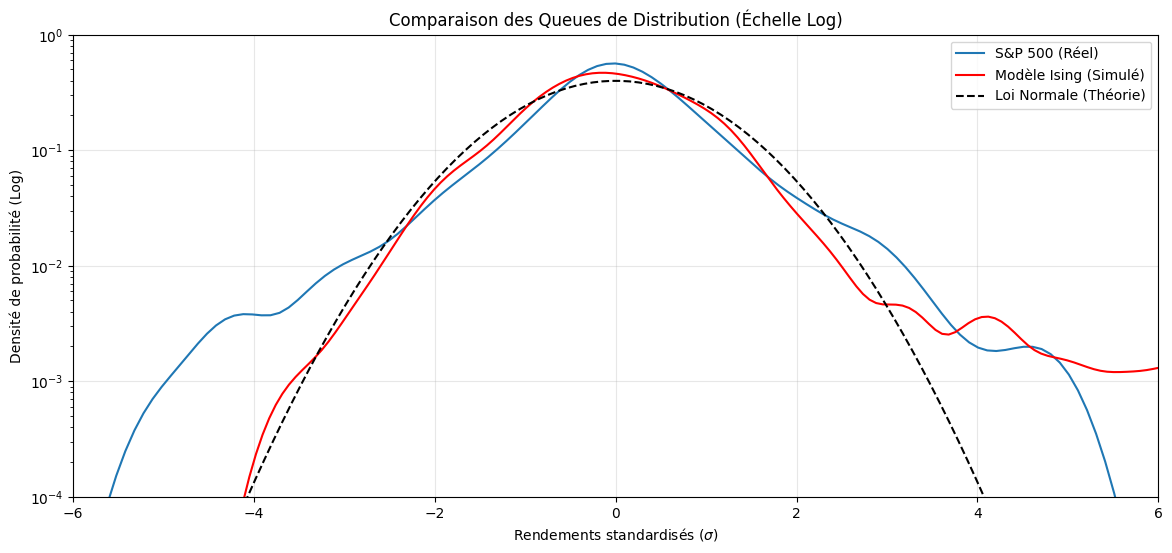

--- Résultats de l'Analyse ---
Volatilité (Ecart-type) : 0.0032059443136420577
Asymétrie (Skewness) : 1.7006213561012835
Excès de Kurtosis : 10.38167313718682
Jarque-Bera p-value : 0.0
Est une Loi Normale ? : False
Susceptibility : 44.77305752681723


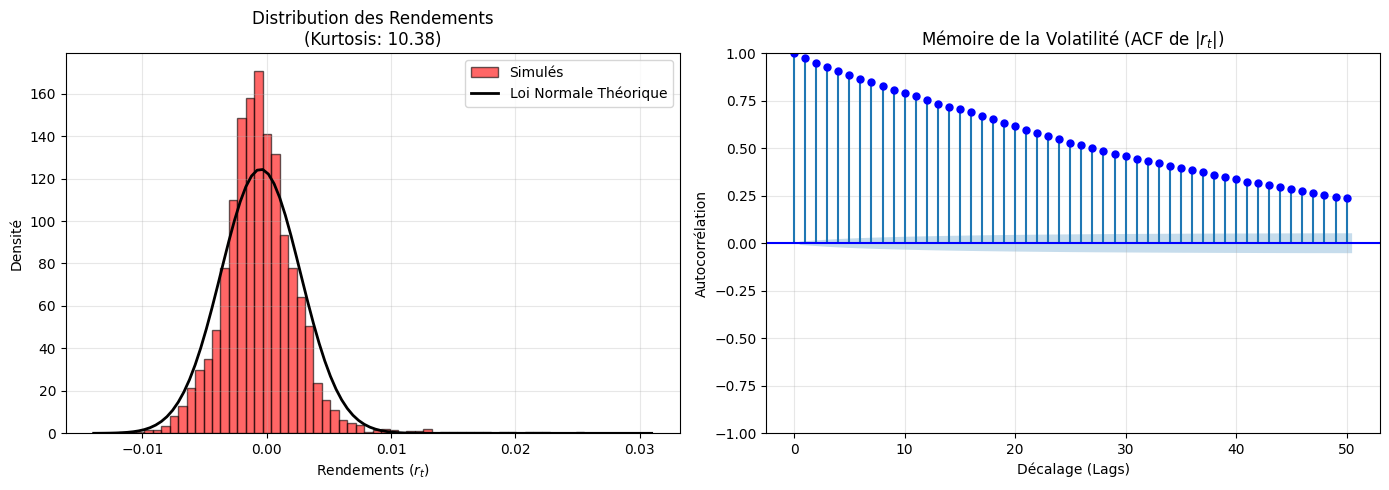

In [69]:
ticker = "BTC-USD"#"^GSPC" # S&P 500 (ou "BTC-USD" pour le Bitcoin)
data = yf.download(ticker, start="2019-01-01", end="2024-01-01")

# Calcul des rendements logarithmiques (log-returns)
real_returns = np.log(data['Close'] / data['Close'].shift(1)).dropna()

def compare_to_reality(sim_returns, real_returns):
    plt.figure(figsize=(14, 6))
    
    # Standardisation (pour comparer des pommes avec des pommes)
    # On ramène les deux distributions à une moyenne de 0 et un écart-type de 1
    sim_std = (sim_returns - sim_returns.mean()) / sim_returns.std()
    real_std = (real_returns - real_returns.mean()) / real_returns.std()
    
    # Plot des distributions
    sns.kdeplot(real_std, label="S&P 500 (Réel)", color='blue', bw_adjust=1.5)
    sns.kdeplot(sim_std, label="Modèle Ising (Simulé)", color='red', bw_adjust=1.5)
    
    # Loi Normale pour référence
    x = np.linspace(-5, 5, 100)
    plt.plot(x, norm.pdf(x), 'k--', label="Loi Normale (Théorie)")
    
    plt.yscale('log') # PASSAGE EN LOG POUR VOIR LES QUEUES
    plt.ylim(1e-4, 1)
    plt.xlim(-6, 6)
    
    plt.title("Comparaison des Queues de Distribution (Échelle Log)")
    plt.xlabel("Rendements standardisés ($\sigma$)")
    plt.ylabel("Densité de probabilité (Log)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Utilise les rendements de ton meilleur run
compare_to_reality(df_kurt_max['r_history'], real_returns) # Remplace chi_vals par tes r_t simulés

analyzer = MarketMetrics(filename_kurt_max)

financial_stats = analyzer.analyze_returns()

print("--- Résultats de l'Analyse ---")
for metric, valeur in financial_stats.items():
    print(f"{metric} : {valeur}")
    
susceptibility = analyzer.calculate_susceptibility(N, T)
print(f"Susceptibility : {susceptibility}")

# 3. Afficher les graphiques de validation (Histogramme + ACF)
analyzer.plot_stylized_facts(burn_in=1000)
